
> **Course: AIML ZG528 AI and ML for Robotics**

>  **Author: Raja vadhana Prabhakar**
raja.vadhana@pilani.bits-pilani.ac.in

> **Objective**:

To implement traditional sampling based path planner by building a probabilistic roadmap (PRM) for 2D motion planning and find collision‑free shortest paths between a start and goal.

In [ ]:
!pip install matplotlib ffmpeg

  Preparing metadata (setup.py) ... done
  Created wheel for ffmpeg: filename=ffmpeg-1.4-py3-none-any.whl size=6083 sha256=510d6500710fec429428f28f2085650de5920f56815c8ee59477fdfe0b6b4070
  Stored in directory: /root/.cache/pip/wheels/56/30/c5/576bdd729f3bc062d62a551be7fefd6ed2f761901568171e4e
Successfully built ffmpeg


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
import random

In [ ]:
class Node:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.coords = (x, y)
        self.neighbors = []

    def distance(self, other):
        return np.hypot(self.x - other.x, self.y - other.y)

    def __lt__(self, other):
        return False

#### Obstacle Collision Check Logic

In [ ]:
def is_collision(p1, p2, obstacles):
    for obs in obstacles:
        for t in np.linspace(0, 1, num=100):
            x = p1.x + t * (p2.x - p1.x)
            y = p1.y + t * (p2.y - p1.y)
            if (obs["x_min"] <= x <= obs["x_max"] and
                obs["y_min"] <= y <= obs["y_max"]):
                return True
    return False


#### Find nearest neighbors

In [ ]:
def find_neighbors(node, nodes, radius, obstacles):
    neighbors = []
    for other in nodes:
        if other is not node and node.distance(other) <= radius:
            if not is_collision(node, other, obstacles):
                neighbors.append(other)
    return neighbors


#### Query phase : Dijikstra's Algorithm

In [ ]:
def dijkstra(start, goal):
    dist = {start: 0}
    prev = {start: None}
    queue = [(0, start)]

    while queue:
        _, current = heapq.heappop(queue)

        if current == goal:
            break

        for neighbor in current.neighbors:
            alt = dist[current] + current.distance(neighbor)
            if neighbor not in dist or alt < dist[neighbor]:
                dist[neighbor] = alt
                prev[neighbor] = current
                heapq.heappush(queue, (alt, neighbor))

    path = []
    node = goal
    while node:
        path.append(node)
        node = prev.get(node)
    return path[::-1]

### Batch PRM*

In [ ]:
def build_prm_star_batch(start, goal, map_size, obstacles, num_samples=200, radius=2.5):
    nodes = [start, goal]
    for _ in range(num_samples):
        x, y = random.uniform(0, map_size[0]), random.uniform(0, map_size[1])
        node = Node(x, y)
        if not any(is_collision(node, node, [obs]) for obs in obstacles):
            nodes.append(node)

    for node in nodes:
        node.neighbors = find_neighbors(node, nodes, radius, obstacles)

    return nodes


### Incremental PRM*

In [ ]:
def build_prm_star_incremental(start, goal, map_size, obstacles, max_samples=500, radius=2.5):
    nodes = [start, goal]
    success = False
    iterations = 0

    while not success and iterations < max_samples:
        x, y = random.uniform(0, map_size[0]), random.uniform(0, map_size[1])
        node = Node(x, y)
        if not any(is_collision(node, node, [obs]) for obs in obstacles):
            nodes.append(node)
            node.neighbors = find_neighbors(node, nodes, radius, obstacles)
            for neighbor in node.neighbors:
                neighbor.neighbors.append(node)

            # Try pathfinding every few iterations
            if iterations % 10 == 0:
                path = dijkstra(start, goal)
                if path and len(path) > 1:
                    success = True
        iterations += 1

    return nodes


#### Visualize Roadmap building

In [ ]:
def visualize(nodes, path, obstacles, title):
    plt.figure(figsize=(8, 8))
    for obs in obstacles:
        plt.fill(
            [obs["x_min"], obs["x_max"], obs["x_max"], obs["x_min"]],
            [obs["y_min"], obs["y_min"], obs["y_max"], obs["y_max"]],
            color="gray", alpha=0.7
        )

    for node in nodes:
        for neighbor in node.neighbors:
            plt.plot([node.x, neighbor.x], [node.y, neighbor.y], 'lightblue', linewidth=0.5)

    if path:
        path_x = [n.x for n in path]
        path_y = [n.y for n in path]
        plt.plot(path_x, path_y, 'r-', linewidth=2, label="Path")

    plt.plot(start.x, start.y, 'go', markersize=10, label="Start")
    plt.plot(goal.x, goal.y, 'ro', markersize=10, label="Goal")
    plt.title(title)
    plt.xlim(0, map_size[0])
    plt.ylim(0, map_size[1])
    plt.grid(True)
    plt.legend()
    plt.show()

### Main Code to Run

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


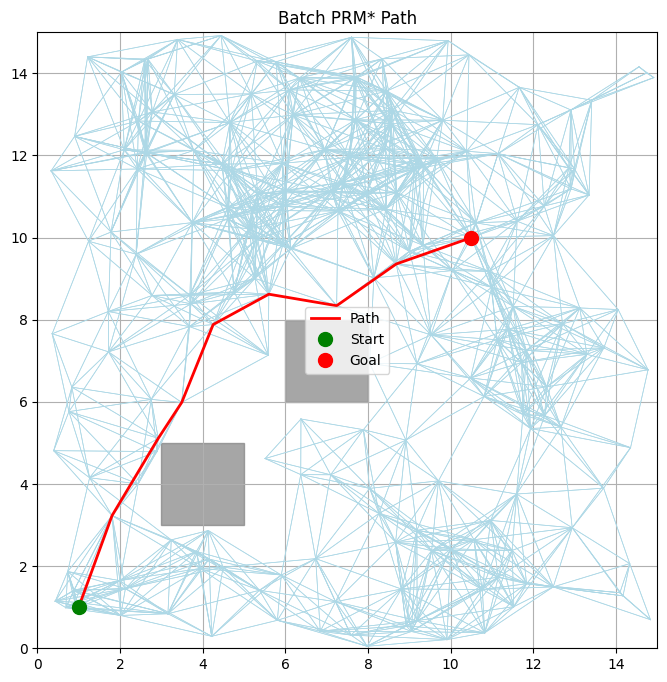

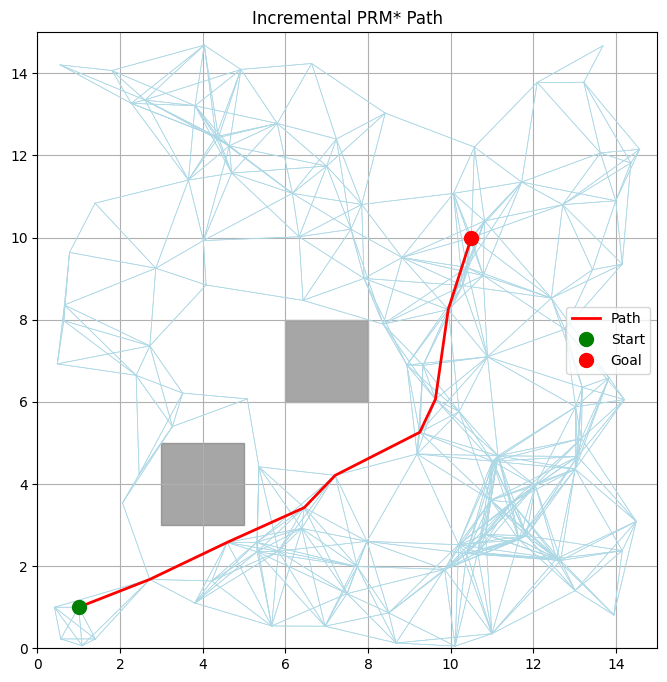

In [ ]:
start = Node(1, 1)
goal = Node(10.5, 10)
map_size = (15, 15)

obstacles = [
    {"x_min": 3.0, "x_max": 5.0, "y_min": 3.0, "y_max": 5.0},
    {"x_min": 6.0, "x_max": 8.0, "y_min": 6.0, "y_max": 8.0}
]

# ---------------------------
# Run Batch PRM*
# ---------------------------
nodes_batch = build_prm_star_batch(start, goal, map_size, obstacles)
path_batch = dijkstra(start, goal)
visualize(nodes_batch, path_batch, obstacles, "Batch PRM* Path")

# ---------------------------
# Run Incremental PRM*
# ---------------------------
# Reset nodes
start = Node(1, 1)
goal = Node(10.5, 10)
nodes_incremental = build_prm_star_incremental(start, goal, map_size, obstacles)
path_incremental = dijkstra(start, goal)
visualize(nodes_incremental, path_incremental, obstacles, "Incremental PRM* Path")


**Exercises:**
1. Replace uniform sampling techniques used for collision check with sophisticated techniques
2. Make the connection radius more adpative based on sample density and map size instead of fixed radius
3. Use A* with a Euclidean heuristic for faster query times when start/goal are known
4. For dynamic replanning, integrate incremental search like D*
5. Measure success rate, planning time, path length, and clearance across many random maps and compare batch vs incremental PRM*
6. Try to impute sudden obstacles during the path building phase and observe the behaviour
7. Try other sampling based planner like RRT* and compare the performance